# **TUẦN 1: 2.1 + 2.2**

In [ ]:
# Cài PySpark (tự lo luôn Spark + Java)
!pip install pyspark -q

# Khởi tạo SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Final") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

print("✅ Spark đã sẵn sàng!")

✅ Spark đã sẵn sàng!


In [ ]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")


Streamlit installed successfully.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install -q gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/"

In [ ]:
# Đọc dữ liệu
orders_df = spark.read.csv(base_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(base_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv(base_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv(base_path + "olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv(base_path + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(base_path + "olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(base_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv(base_path + "product_category_name_translation.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv(base_path + "olist_geolocation_dataset.csv", header=True, inferSchema=True)
print("Đã đọc xong 9 file CSV")

Đã đọc xong 9 file CSV


In [ ]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [ ]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [ ]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [ ]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [ ]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [ ]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [ ]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [ ]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [ ]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [ ]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows

Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|      

# **TUẦN 1: 2.4.Tiền xử lý dữ liệu**

In [ ]:
from pyspark.sql.functions import *

In [ ]:
# Geolocation
geo_customers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("customer_zip_code_prefix"),
    col("geolocation_city").alias("customer_geo_city"),
    col("geolocation_state").alias("customer_geo_state")
).dropDuplicates()

customers_df = customers_df.join(geo_customers, "customer_zip_code_prefix", "left")

geo_sellers = geolocation_df.select(
    col("geolocation_zip_code_prefix").alias("seller_zip_code_prefix"),
    col("geolocation_city").alias("seller_geo_city"),
    col("geolocation_state").alias("seller_geo_state")
).dropDuplicates()

sellers_df = sellers_df.join(geo_sellers, "seller_zip_code_prefix", "left")

In [ ]:
# Timestamp & Cast
orders_df = orders_df \
    .withColumn("order_purchase_timestamp", try_to_timestamp(col("order_purchase_timestamp"))) \
    .withColumn("order_approved_at", try_to_timestamp(col("order_approved_at"))) \
    .withColumn("order_delivered_carrier_date", try_to_timestamp(col("order_delivered_carrier_date"))) \
    .withColumn("order_delivered_customer_date", try_to_timestamp(col("order_delivered_customer_date"))) \
    .withColumn("order_estimated_delivery_date", try_to_timestamp(col("order_estimated_delivery_date")))

reviews_df = reviews_df \
    .withColumn("review_creation_date", try_to_timestamp(col("review_creation_date"))) \
    .withColumn("review_answer_timestamp", try_to_timestamp(col("review_answer_timestamp")))

order_items_df = order_items_df \
    .withColumn("shipping_limit_date", try_to_timestamp(col("shipping_limit_date"))) \
    .withColumn("price", col("price").cast("double")) \
    .withColumn("freight_value", col("freight_value").cast("double"))

payments_df = payments_df.withColumn("payment_value", col("payment_value").cast("double"))

from pyspark.sql.functions import expr

reviews_df = reviews_df \
    .withColumn("review_score", expr("try_cast(review_score as int)"))
#reviews_df = reviews_df.withColumn("review_score", col("review_score").cast("int"))


In [ ]:
# Aggregate
order_items_agg = order_items_df.groupBy("order_id").agg(
    first("product_id").alias("product_id"),
    first("seller_id").alias("seller_id"),
    sum("price").alias("total_price"),
    sum("freight_value").alias("total_freight_value"),
    count("order_item_id").alias("num_items")
)

payments_agg = payments_df.groupBy("order_id").agg(
    sum("payment_value").alias("total_payment_value"),
    first("payment_type").alias("payment_type")
)

In [ ]:
# JOIN
df_master = orders_df.alias("o") \
    .join(customers_df.alias("c"), col("o.customer_id") == col("c.customer_id"), "left") \
    .drop(col("c.customer_id")) \
    .join(order_items_agg.alias("oi"), col("o.order_id") == col("oi.order_id"), "left") \
    .drop(col("oi.order_id")) \
    .join(payments_agg.alias("op"), col("o.order_id") == col("op.order_id"), "left") \
    .drop(col("op.order_id")) \
    .join(reviews_df.alias("r"), col("o.order_id") == col("r.order_id"), "left") \
    .drop(col("r.order_id")) \
    .join(products_df.alias("p"), col("oi.product_id") == col("p.product_id"), "left") \
    .drop(col("p.product_id")) \
    .join(sellers_df.alias("s"), col("oi.seller_id") == col("s.seller_id"), "left") \
    .drop(col("s.seller_id")) \
    .join(category_df.alias("t"), col("p.product_category_name") == col("t.product_category_name"), "left") \
    .drop(col("t.product_category_name"))

In [ ]:
# ================================
# XỬ LÝ MISSING VALUES (FINAL)
# ================================

df_master = df_master.fillna({
    # TEXT
    "review_comment_message": "",
    "review_comment_title": "",

    # CATEGORICAL
    "payment_type": "unknown",
    "product_category_name_english": "unknown",

    # NUMERICAL (logic)
    # Removed "delivery_delay_days": 0, as it's created later
    "num_items": 1,

    # NUMERICAL (bổ sung)
    "total_payment_value": 0,
    "total_price": 0,
    "total_freight_value": 0
})

# Drop key quan trọng
df_master = df_master.dropna(subset=["order_id"])

print("✅ Missing values đã xử lý đầy đủ")

✅ Missing values đã xử lý đầy đủ


In [ ]:
# Feature Engineering
df_master = df_master \
    .withColumn("delivery_delay_days", datediff(col("order_delivered_customer_date"), col("order_estimated_delivery_date"))) \
    .withColumn("total_order_value", col("total_price") + col("total_freight_value")) \
    .withColumn("is_late_delivery", when(col("order_delivered_customer_date") > col("order_estimated_delivery_date"), 1).otherwise(0))

# ÉP 1 DÒNG CHO 1 ORDER_ID
df_master = df_master.dropDuplicates(["order_id"])

In [ ]:
# =====================================
# 10. Kiểm tra kết quả
# =====================================
df_master = df_master.cache()

print("\n" + "="*60)
print("=== KẾT QUẢ SAU TIỀN XỬ LÝ ===")
print("Tổng số bản ghi :", df_master.count())
print("Tổng số cột     :", len(df_master.columns))
print("="*60)

# In Schema
df_master.printSchema()

# Kiểm tra Null counts chi tiết (vertical)
print("\n" + "="*60)
print("NULL COUNTS DETAIL:")
exprs = [count(when(col(c).isNull(), True)).alias(c) for c in df_master.columns]
null_counts = df_master.select(exprs)
null_counts.show(vertical=True, truncate=False)
print("="*60)

# =====================================
# 11. Lưu file Parquet
# =====================================
output_path = base_path + "olist_master_processed.parquet"
df_master.write.mode("overwrite").parquet(output_path)
print(f"\nĐã lưu thành công vào: {output_path}")


=== KẾT QUẢ SAU TIỀN XỬ LÝ ===
Tổng số bản ghi : 99441
Tổng số cột     : 44
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_geo_city: string (nullable = true)
 |-- customer_geo_state: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- total_price: double (nullable = false)
 |-- total_freight_value: double (nullable = false)
 |-- num_item

# **IV.4 – Regression**

In [ ]:
from pyspark.sql.functions import col

target_col = "payment_value"

# Bắt đầu từ payments_df
df_ml = payments_df.select(
    col("order_id"),
    col("payment_value").alias(target_col),
    col("payment_type"),
    col("payment_installments"),
    col("payment_sequential")
)

# Join với các feature aggregate từ order_items, products, orders, customers...
# (Giả sử bạn đã có df_master hoặc build riêng)
feature_df = df_master.select(   # hoặc join nhiều bảng
    "order_id",
    "total_price",           # tổng giá trị sản phẩm trong order
    "total_freight_value",
    "num_items",
    "product_weight_g",
    "product_category_name_english",
    "customer_state",        # nếu có
    "seller_state",          # nếu có
    "order_status"
)

df_ml = df_ml.join(feature_df, on="order_id", how="left")

# Lọc null target
df_ml = df_ml.filter(col(target_col).isNotNull())
print(f"Số mẫu: {df_ml.count()}")

Số mẫu: 103886


In [ ]:
# ==================== FEATURES PHÙ HỢP VỚI payment_value ====================
numeric_cols = [
    "total_price",
    "total_freight_value",
    "num_items",
    "product_weight_g",
    "payment_installments"
]

categorical_cols = [
    "payment_type",
    "product_category_name_english",
    "customer_state",
    "seller_state",
    "order_status"
]

In [ ]:
# Xử lý outlier bằng IQR cho payment_value
q1, q3 = df_ml.approxQuantile(target_col, [0.25, 0.75], 0.05)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_reg = df_ml.filter((col(target_col) >= lower) & (col(target_col) <= upper))

print(f"Số mẫu sau khi lọc outlier (IQR): {df_reg.count()}")
print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")

Số mẫu sau khi lọc outlier (IQR): 95414
Lower bound: -106.23 | Upper bound: 333.61


In [ ]:
# ====================== 3. FILLNA (quan trọng - phải làm trên df_reg) ======================
df_reg = df_reg.fillna({
    # Numeric columns
    "total_price": 0.0,
    "total_freight_value": 0.0,
    "num_items": 0,
    "product_weight_g": 0,
    "payment_installments": 1,

    # Categorical columns
    "payment_type": "unknown",
    "product_category_name_english": "unknown",
    "customer_state": "unknown",
    "seller_state": "unknown",
    "order_status": "unknown"
})

print(f"Đã fillna xong. Số mẫu cuối cùng: {df_reg.count()}")

Đã fillna xong. Số mẫu cuối cùng: 95414


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# ====================== PIPELINE FEATURES ======================

# 1. StringIndexer cho các cột categorical
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_cols]

# 2. OneHotEncoder
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_vec", handleInvalid="keep") for c in categorical_cols]

# 3. Danh sách features cuối cùng đưa vào model
feature_cols = numeric_cols + [c + "_vec" for c in categorical_cols]
# 4. VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

print("✅ Feature pipeline đã được cập nhật cho target = payment_value")
print(f"Số lượng numeric features : {len(numeric_cols)}")
print(f"Số lượng categorical features: {len(categorical_cols)}")
print(f"Tổng features đưa vào model: {len(feature_cols)}")

✅ Feature pipeline đã được cập nhật cho target = payment_value
Số lượng numeric features : 5
Số lượng categorical features: 5
Tổng features đưa vào model: 10


In [ ]:
# ====================== TRAIN - TEST SPLIT ======================
train_df, test_df = df_reg.randomSplit([0.8, 0.2], seed=42)

print(f"Train size: {train_df.count():,}")
print(f"Test size : {test_df.count():,}")

Train size: 76,325
Test size : 19,089


In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
import time

# ====================== LINEAR REGRESSION ======================
lr = LinearRegression(
    featuresCol="features",
    labelCol=target_col,           # target_col = "payment_value"
    regParam=0.01,
    elasticNetParam=0.0,
    maxIter=100,
    standardization=True
)

# Pipeline
pipeline_lr = Pipeline(stages=indexers + encoders + [assembler, lr])

# Training
start = time.time()
model_lr = pipeline_lr.fit(train_df)
train_time_lr = time.time() - start

print(f"✅ Linear Regression train xong trong {train_time_lr:.2f} giây")

# Prediction
pred_lr = model_lr.transform(test_df)

✅ Linear Regression train xong trong 71.60 giây


In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor
import time

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol=target_col,      # payment_value
    maxDepth=8,
    maxBins=64,
    minInstancesPerNode=5,
    seed=42
)

pipeline_dt = Pipeline(stages=indexers + encoders + [assembler, dt])

start = time.time()
model_dt = pipeline_dt.fit(train_df)
train_time_dt = time.time() - start

pred_dt = model_dt.transform(test_df)

print(f"✅ Decision Tree train xong trong {train_time_dt:.2f} giây")

✅ Decision Tree train xong trong 136.71 giây


In [ ]:
from pyspark.ml.regression import RandomForestRegressor
import time

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_col,           # payment_value
    numTrees=100,
    maxDepth=12,
    maxBins=64,
    subsamplingRate=0.8,           # ← Sửa thành subsamplingRate (2 chữ s)
    seed=42,
    featureSubsetStrategy="sqrt"
)

pipeline_rf = Pipeline(stages=indexers + encoders + [assembler, rf])

start = time.time()
model_rf = pipeline_rf.fit(train_df)
train_time_rf = time.time() - start

pred_rf = model_rf.transform(test_df)

print(f"✅ Random Forest train xong trong {train_time_rf:.2f} giây")

✅ Random Forest train xong trong 1266.40 giây


In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

def eval_reg(pred, name, train_time):
    rmse = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="rmse"
    ).evaluate(pred)

    mae = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="mae"
    ).evaluate(pred)

    r2 = RegressionEvaluator(
        labelCol=target_col, predictionCol="prediction", metricName="r2"
    ).evaluate(pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print("Train time:", train_time)

    return [name, rmse, mae, r2, train_time]

results_reg = []
results_reg.append(eval_reg(pred_lr, "Linear Regression", train_time_lr))
results_reg.append(eval_reg(pred_dt, "Decision Tree", train_time_dt))
results_reg.append(eval_reg(pred_rf, "Random Forest", train_time_rf))


Linear Regression
RMSE: 32.648245145881766
MAE : 18.714004193467144
R2  : 0.7871400911068881
Train time: 71.60191893577576

Decision Tree
RMSE: 20.469973085430496
MAE : 8.25958287275148
R2  : 0.9163224936013962
Train time: 136.70649766921997

Random Forest
RMSE: 33.34773540134428
MAE : 22.64785462784424
R2  : 0.7779213134406752
Train time: 1266.4009187221527


=== So sánh hiệu suất 3 mô hình ===
               Model     RMSE      MAE      R²  Train Time
0  Linear Regression  32.6482  18.7140  0.7871     71.6019
1      Decision Tree  20.4700   8.2596  0.9163    136.7065
2      Random Forest  33.3477  22.6479  0.7779   1266.4009


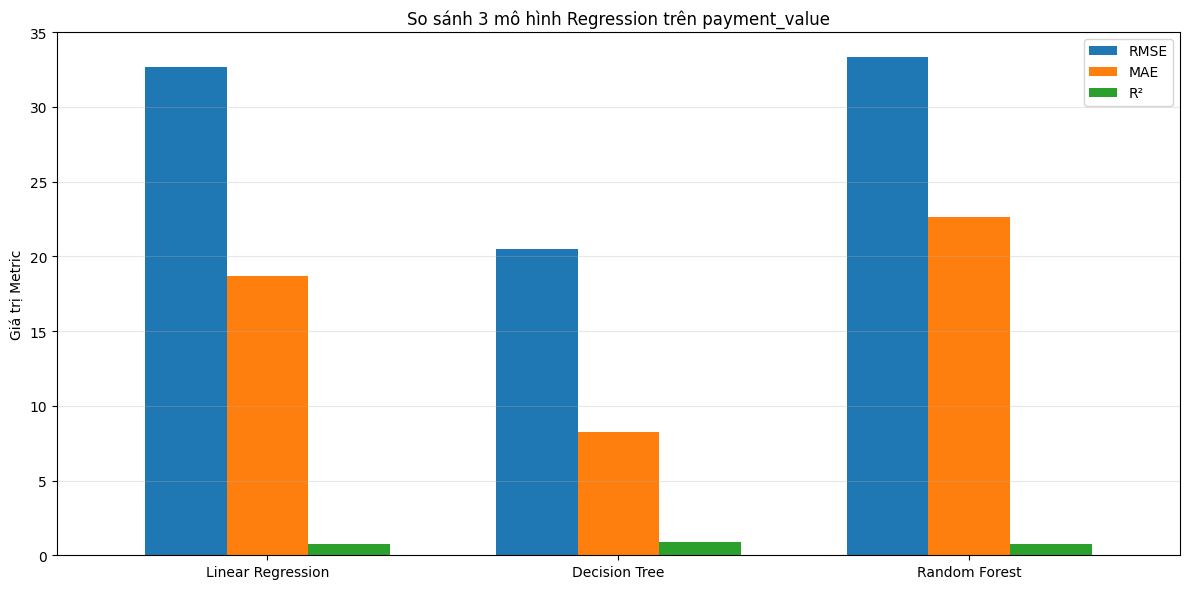

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Chuyển kết quả thành DataFrame
df_compare = pd.DataFrame(results_reg,
                          columns=["Model", "RMSE", "MAE", "R²", "Train Time"])

print("=== So sánh hiệu suất 3 mô hình ===")
print(df_compare.round(4))

# Vẽ biểu đồ so sánh
df_compare.set_index("Model")[["RMSE", "MAE", "R²"]].plot(
    kind="bar",
    figsize=(12, 6),
    width=0.7
)
plt.title("So sánh 3 mô hình Regression trên payment_value")
plt.ylabel("Giá trị Metric")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra mối tương quan giữa total_price và payment_value
df_reg.selectExpr(
    "corr(total_price, payment_value) as correlation",
    "avg(payment_value) as mean_payment",
    "avg(total_price) as mean_total_price"
).show()

+------------------+------------------+-----------------+
|       correlation|      mean_payment| mean_total_price|
+------------------+------------------+-----------------+
|0.8000904637189422|108.88487538515831|94.68100121581782|
+------------------+------------------+-----------------+



In [ ]:
# FIX: tránh bị đè hàm min bởi pyspark.sql.functions.min
import builtins

best_result = builtins.min(results_reg, key=lambda x: x[1])  # x[1] = RMSE

best_model_name = best_result[0]
best_rmse = best_result[1]

print("\n" + "="*50)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   RMSE = {best_rmse:.2f}")
print("="*50)


🏆 BEST MODEL: Decision Tree
   RMSE = 20.47


In [ ]:
if best_model_name == "Linear Regression":
    best_model = model_lr
elif best_model_name == "Decision Tree":
    best_model = model_dt
elif best_model_name == "Random Forest":
    best_model = model_rf

In [ ]:
import shutil

save_path = "/content/drive/MyDrive/models_lamlai/best_regression_model"

# Xóa folder cũ nếu có
shutil.rmtree(save_path, ignore_errors=True)

# Lưu PipelineModel
best_model.write().overwrite().save(save_path)

print("✅ Model saved at:", save_path)

✅ Model saved at: /content/drive/MyDrive/models_lamlai/best_regression_model


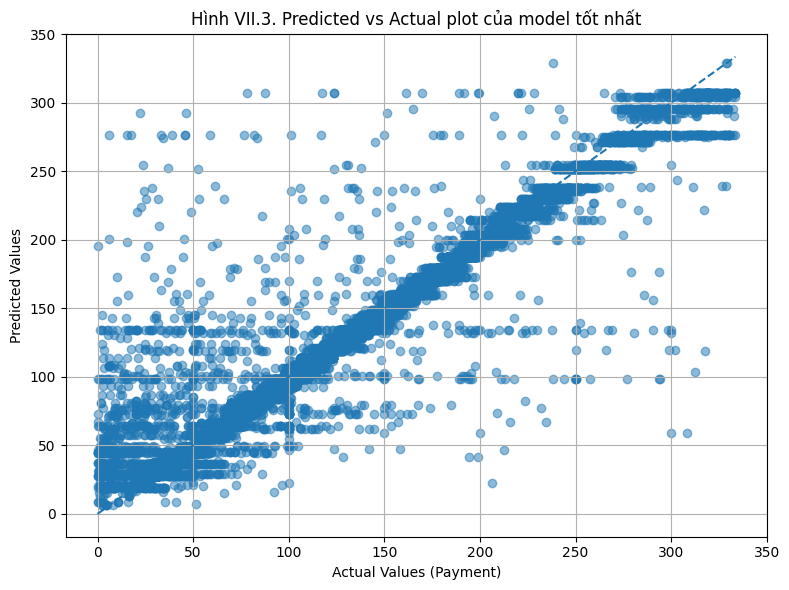

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pred_df = best_model.transform(test_df)

pdf = pred_df.select("payment_value", "prediction").toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pdf["payment_value"], pdf["prediction"], alpha=0.5)

# FIX lỗi min/max
min_val = np.minimum(pdf["payment_value"].min(), pdf["prediction"].min())
max_val = np.maximum(pdf["payment_value"].max(), pdf["prediction"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Values (Payment)")
plt.ylabel("Predicted Values")
plt.title("Hình VII.3. Predicted vs Actual plot của model tốt nhất")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Cách 2: Lấy tên chi tiết sau OneHot (khuyến nghị nếu muốn xem rõ)
from pyspark.ml.feature import OneHotEncoderModel

feature_names_expanded = []

for stage in model_rf.stages:
    if isinstance(stage, OneHotEncoderModel):
        # Lấy tên cột gốc
        orig_col = stage.getInputCol().replace("_idx", "")
        # Lấy số lượng categories
        categories = stage.categorySizes[0]   # vì mỗi encoder chỉ 1 cột
        for i in range(categories):           # hoặc range(categories-1) nếu dropLast=True
            feature_names_expanded.append(f"{orig_col}_{i}")
    elif isinstance(stage, VectorAssembler):
        # Nếu muốn giữ numeric + onehot đã mở rộng
        break

# Kết hợp numeric + onehot expanded
all_features = numeric_cols + feature_names_expanded

fi_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi_df.head(15))

                              feature  importance
0                         total_price    0.576344
1                 total_freight_value    0.127847
4                payment_installments    0.079648
3                    product_weight_g    0.078793
7                      payment_type_2    0.029346
2                           num_items    0.021119
18    product_category_name_english_7    0.009067
17    product_category_name_english_6    0.007771
111                    seller_state_0    0.007454
5                      payment_type_0    0.006729
6                      payment_type_1    0.005836
25   product_category_name_english_14    0.005583
30   product_category_name_english_19    0.004905
122                   seller_state_11    0.003309
83                   customer_state_0    0.003300


In [ ]:
import pandas as pd

# Tạo DataFrame
fi_df = pd.DataFrame(feature_importance_sorted, columns=["Feature", "Importance"])

# Lấy Top 5
top5 = fi_df.head(5)

# In bảng đẹp
print("\nTOP 5 FEATURE IMPORTANCE:")
print(top5.to_string(index=False))


TOP 5 FEATURE IMPORTANCE:
             Feature  Importance
         total_price    0.576344
 total_freight_value    0.127847
payment_installments    0.079648
    product_weight_g    0.078793
      payment_type_2    0.029346


In [ ]:
import pandas as pd

fi_df = pd.DataFrame(feature_importance_sorted, columns=["Feature", "Importance"])

save_fi_path = "/content/drive/MyDrive/models_lamlai/feature_importance.csv"
fi_df.to_csv(save_fi_path, index=False)

print("Feature importance saved at:", save_fi_path)

Feature importance saved at: /content/drive/MyDrive/models_lamlai/feature_importance.csv


Feature importance saved at: /content/drive/MyDrive/models_sau/feature_importance.csv


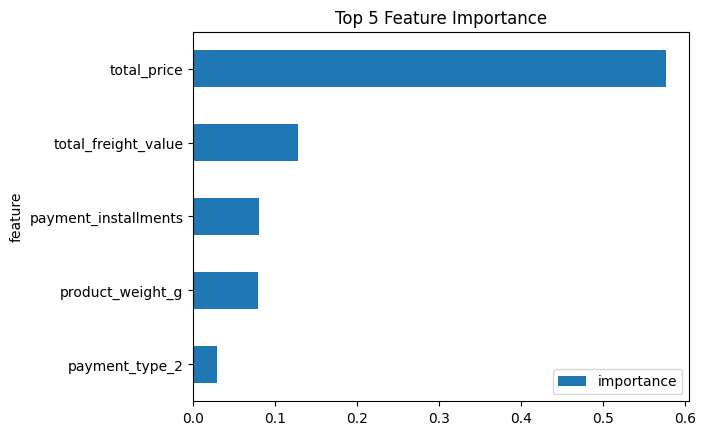

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tạo DataFrame
fi_df = pd.DataFrame(feature_importance_sorted, columns=["feature", "importance"])

# Lấy top 5
top5 = fi_df.head(5)

# Lưu file
save_fi_path = "/content/drive/MyDrive/models_sau/feature_importance.csv"
fi_df.to_csv(save_fi_path, index=False)

print("Feature importance saved at:", save_fi_path)

# Vẽ biểu đồ
top5.plot(kind='barh', x='feature', y='importance')
plt.title("Top 5 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# ====================== RESIDUAL ANALYSIS ======================

from pyspark.sql.functions import col, mean, stddev, min as spark_min, max as spark_max

def residual_analysis(pred_df, name):

    print(f"\n=== Residual Analysis: {name} ===")

    # 1. Tạo residual
    df_res = pred_df.withColumn("residual", col("payment_value") - col("prediction"))

    # 2. Thống kê cơ bản
    stats = df_res.select(
        mean("residual").alias("mean_residual"),
        stddev("residual").alias("std_residual"),
        spark_min("residual").alias("min_residual"),
        spark_max("residual").alias("max_residual")
    )

    stats.show(truncate=False)

    # 3. MAE từ residual (check lại)
    df_res.selectExpr("avg(abs(residual)) as MAE_check").show()

    # 4. Xem vài dòng lỗi lớn nhất
    print("Top residual lớn nhất:")
    df_res.orderBy(col("residual").desc()).select(
        "payment_value", "prediction", "residual"
    ).show(5, truncate=False)

    print("Top residual âm lớn nhất:")
    df_res.orderBy(col("residual").asc()).select(
        "payment_value", "prediction", "residual"
    ).show(5, truncate=False)

    return df_res


# ================= RUN =================
res_lr = residual_analysis(pred_lr, "Linear Regression")
res_dt = residual_analysis(pred_dt, "Decision Tree")
res_rf = residual_analysis(pred_rf, "Random Forest")


=== Residual Analysis: Linear Regression ===
+-------------------+-----------------+------------------+-----------------+
|mean_residual      |std_residual     |min_residual      |max_residual     |
+-------------------+-----------------+------------------+-----------------+
|0.18492196919511444|32.64857661461156|-940.4860717451096|239.6216712939615|
+-------------------+-----------------+------------------+-----------------+

+------------------+
|         MAE_check|
+------------------+
|18.714004193467147|
+------------------+

Top residual lớn nhất:
+-------------+------------------+------------------+
|payment_value|prediction        |residual          |
+-------------+------------------+------------------+
|50.0         |-189.6216712939615|239.6216712939615 |
|317.88       |109.89734221373693|207.98265778626308|
|299.98       |121.43796604835283|178.54203395164717|
|312.49       |149.0535304172516 |163.4364695827484 |
|293.4        |135.00138111583047|158.3986188841695 |
+------

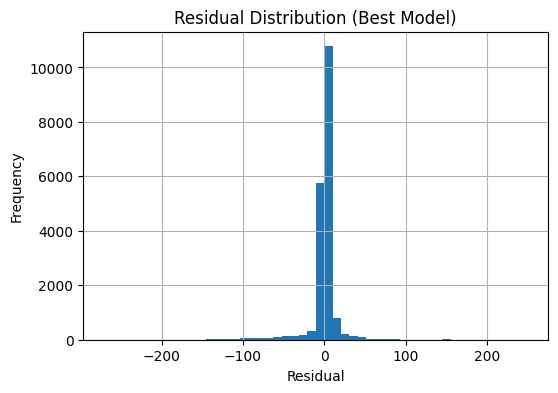

In [ ]:
# ================= RESIDUAL DISTRIBUTION =================

import matplotlib.pyplot as plt
import scipy.stats as stats

# Lấy residual từ Decision Tree
pdf_res = res_dt.select("residual").toPandas()

# 1. Histogram
plt.figure(figsize=(6,4))
plt.hist(pdf_res["residual"], bins=50)
plt.title("Residual Distribution (Best Model)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


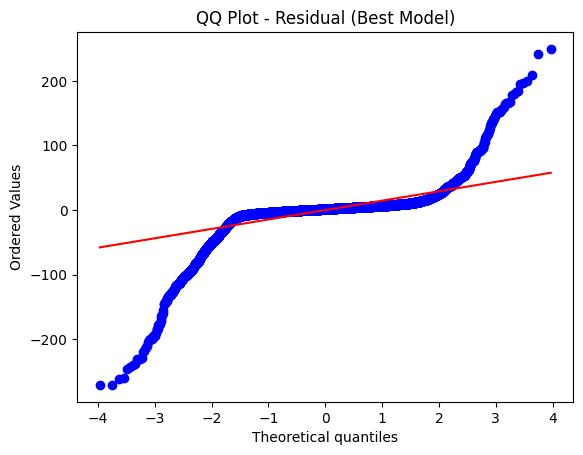

In [ ]:
# 2. QQ Plot
stats.probplot(pdf_res["residual"], dist="norm", plot=plt)
plt.title("QQ Plot - Residual (Best Model)")
plt.show()

In [ ]:
df_ml.selectExpr("avg(payment_value)").show()

+------------------+
|avg(payment_value)|
+------------------+
|154.10038041698587|
+------------------+

